## Decision Tree 

### Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

### Exploration

In [27]:
xls = pd.ExcelFile("heart_disease.xlsx")
print(xls.sheet_names)

['Description', 'Heart_disease']


In [28]:
df = pd.read_excel('heart_disease.xlsx',sheet_name='Heart_disease')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    str    
 2   cp        908 non-null    str    
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    object 
 6   restecg   908 non-null    str    
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    str    
 11  thal      908 non-null    str    
 12  num       908 non-null    int64  
dtypes: float64(1), int64(5), object(2), str(5)
memory usage: 132.0+ KB


In [30]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [31]:
print("\nMissing Values:")
df.isnull().sum()


Missing Values:


age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

### Visualizations

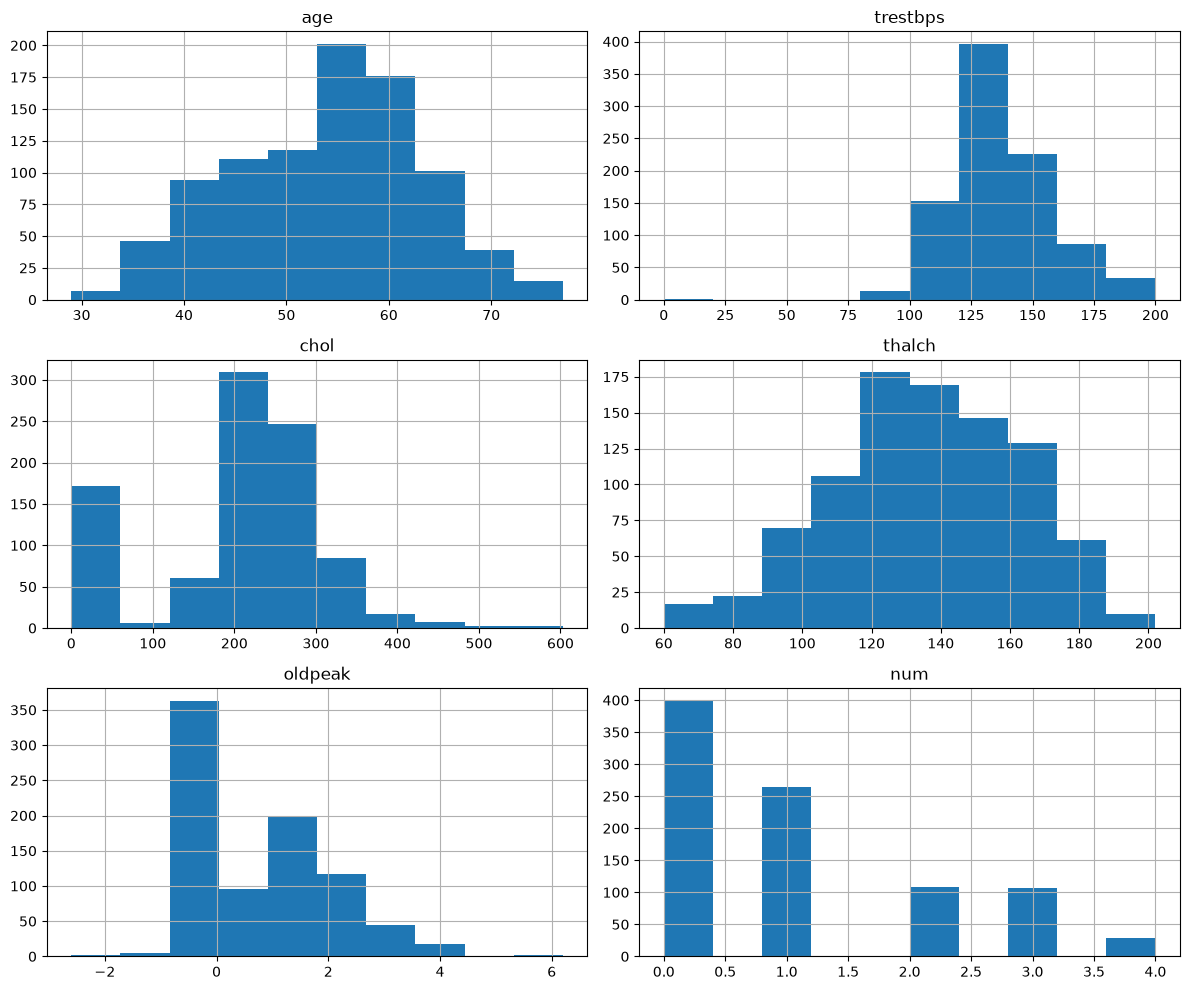

In [32]:
# Histograms
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

* Age: Most patients are between 50 and 60 years, with very few patients below 35 or above 70.
* Resting Blood Pressure (trestbps): Most resting blood pressure values are concentrated around 120–140 mmHg, with a few higher values.
* Cholesterol (chol): Cholesterol levels are mostly between 180 and 300 mg/dL, with some extreme high values indicating possible outliers.
* Maximum Heart Rate (thalch): The maximum heart rate is mostly distributed between 120 and 170 bpm, with a roughly bell-shaped pattern.
* Oldpeak: Most patients have low ST depression (0–2), while higher values are less common and may represent outliers.
* Target (num): The target variable is imbalanced, with class 0 (no heart disease) occurring more frequently than the other classes.


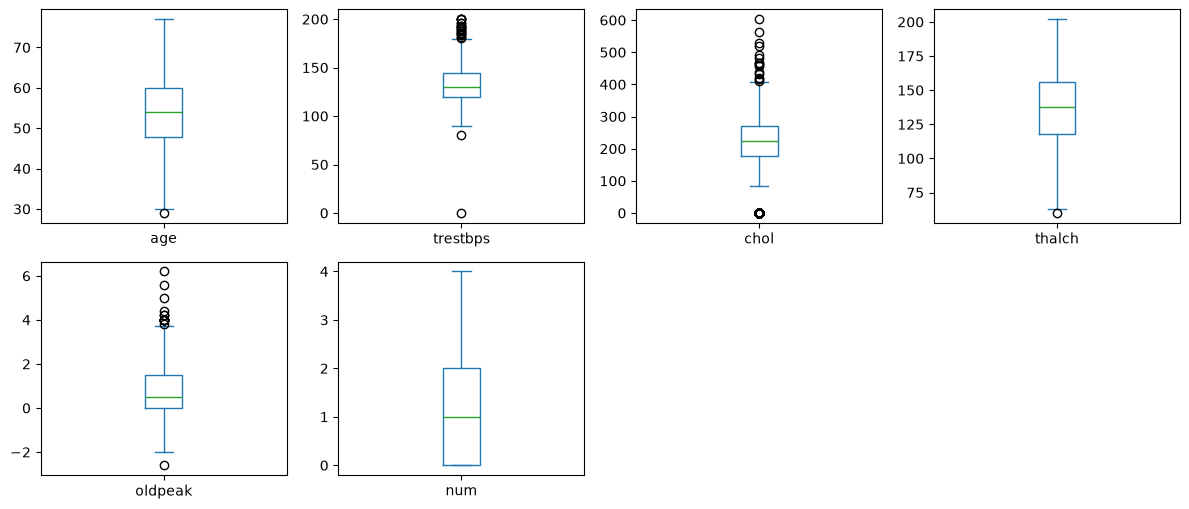

In [33]:
# Boxplots
df.plot(kind='box', subplots=True, layout=(4,4), figsize=(12,10), sharex=False)
plt.tight_layout()
plt.show()

* Age: Most patients are between 48 and 60 years, with only a few unusually young or old patients appearing as outliers.
* Trestbps: Resting blood pressure is mainly between 120 and 145 mmHg, with several high-value outliers and one very low outlier.
* Chol: Cholesterol values show many outliers, indicating that a few patients have extremely high cholesterol levels.
* Thalch: Maximum heart rate is mostly between 120 and 155 bpm, with only a few low-value outliers.
* Oldpeak: Most patients have low ST depression values, while a few patients have unusually high or low values that appear as outliers.
* Num: The target variable is categorical, so the boxplot is not meaningful for identifying outliers or data distribution.


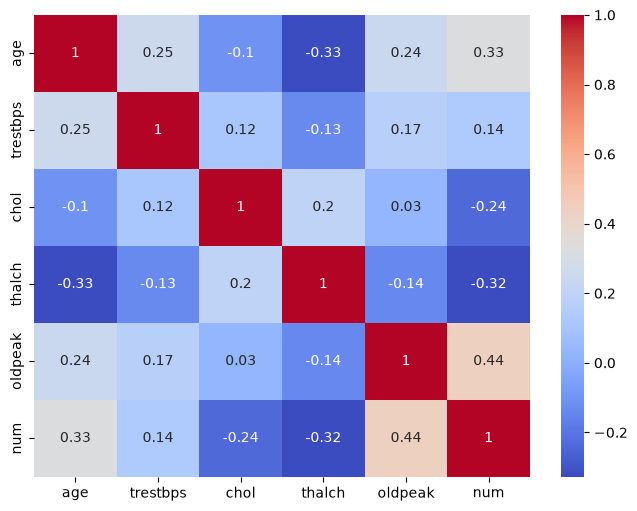

In [34]:
# Correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

Most features have weak correlations with each other, while oldpeak shows the strongest positive correlation with the target, indicating it is an important predictor of heart disease.


### Missing values

In [35]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [36]:
#Filling missing values in oldpeak
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())

In [37]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

### Feature Engineering

In [38]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

for col in categorical_cols:
    print(col, df[col].map(type).unique())

sex [<class 'str'>]
cp [<class 'str'>]
fbs [<class 'bool'> <class 'str'>]
restecg [<class 'str'>]
exang [<class 'bool'> <class 'str'>]
slope [<class 'str'>]
thal [<class 'str'>]


In [39]:
print(df['fbs'].unique())
print(df['exang'].unique())

[True False 'FALSE' 'TRUE']
[False True 'FALSE' 'TURE']


In [40]:
#Fixing inconsistent values
df['fbs'] = df['fbs'].replace({True:'TRUE',False:'FALSE'})
df['exang'] = df['exang'].replace({True:'TRUE',False:'FALSE','TURE':'TRUE'})

In [41]:
for col in categorical_cols:
    print(col, df[col].map(type).unique())

sex [<class 'str'>]
cp [<class 'str'>]
fbs [<class 'str'>]
restecg [<class 'str'>]
exang [<class 'str'>]
slope [<class 'str'>]
thal [<class 'str'>]


In [42]:
le = LabelEncoder()

categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [43]:
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,1,0,150,0,2.3,0,0,0
1,41,1,1,135,203,0,1,132,0,0.0,1,0,0
2,57,1,0,140,192,0,1,148,0,0.4,1,0,0
3,52,1,3,118,186,0,0,190,0,0.0,1,0,0
4,57,1,0,110,201,0,1,126,1,1.5,1,0,0


### Decision Tree Model

In [44]:
X = df.drop('num', axis=1)
y = df['num']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
#Stratify to prevent imbalance

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test,y_pred))

Accuracy: 0.46153846153846156


In [46]:
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))


Classification Report

              precision    recall  f1-score   support

           0       0.74      0.66      0.70        80
           1       0.37      0.38      0.37        53
           2       0.21      0.23      0.22        22
           3       0.19      0.24      0.21        21
           4       0.17      0.17      0.17         6

    accuracy                           0.46       182
   macro avg       0.33      0.33      0.33       182
weighted avg       0.48      0.46      0.47       182



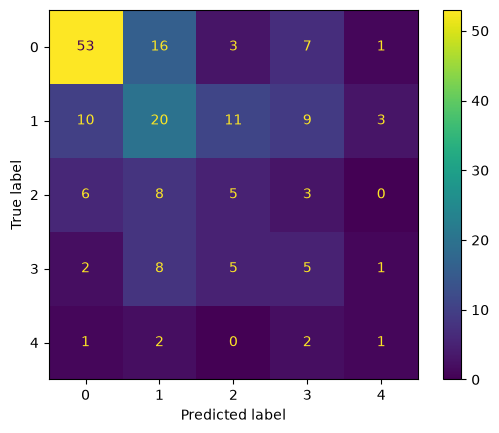

In [47]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

In [48]:
# Hyperparameter Tuning
params = {
    'criterion':['gini','entropy'],
    'max_depth':[3,5,7,None],
    'min_samples_split':[2,5,10]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42),params,cv=5,scoring='accuracy')

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_model = grid.best_estimator_
pred = best_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, pred))

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Best CV Score: 0.5647236655644781
Test Accuracy: 0.5054945054945055


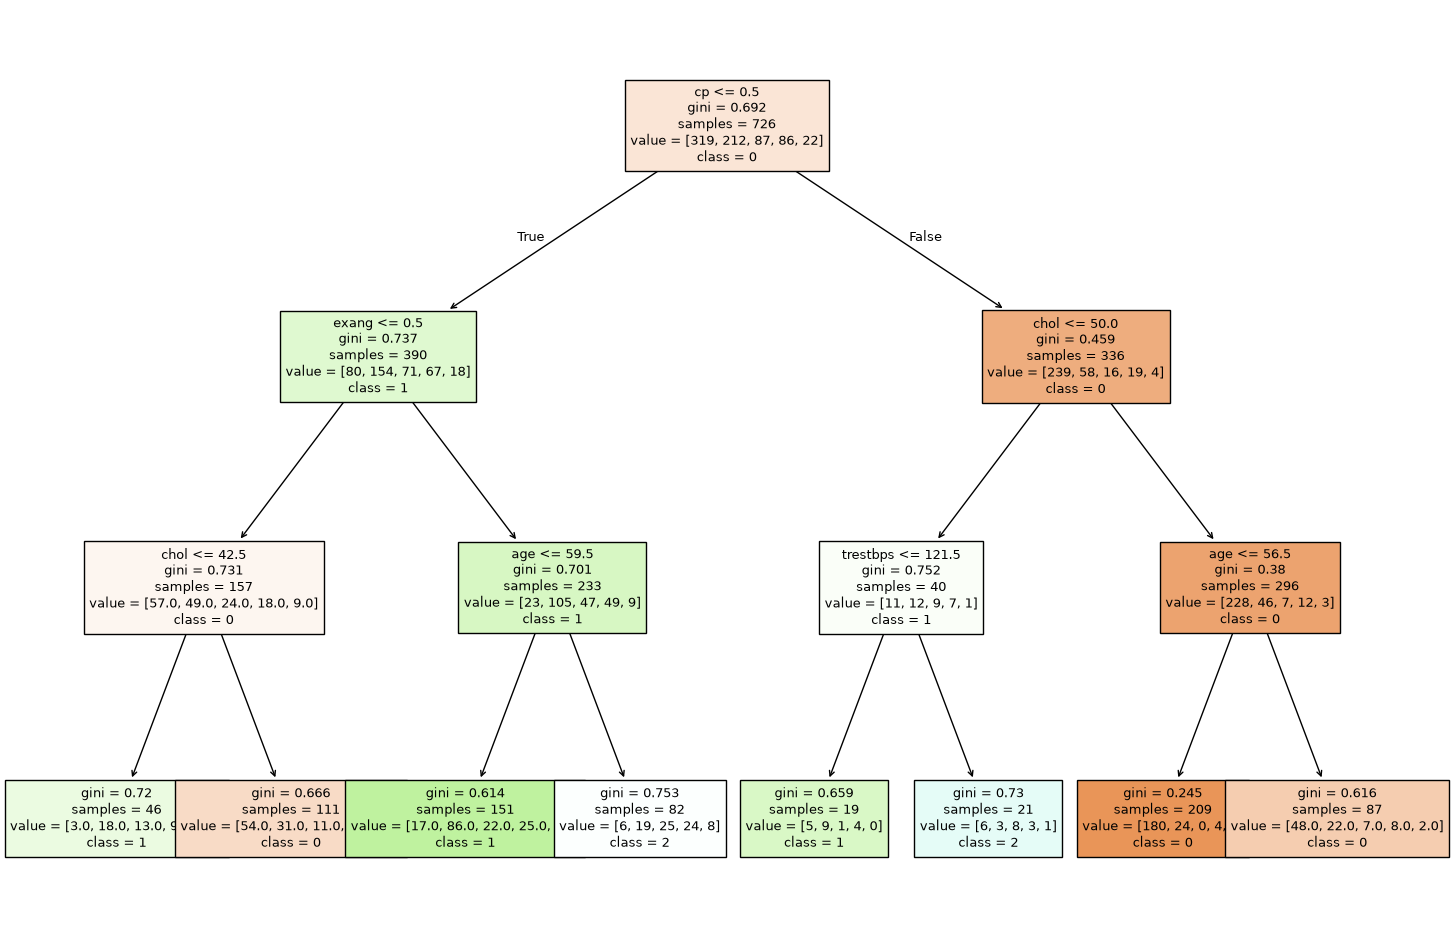

In [49]:
plt.figure(figsize=(18,12))
plot_tree(best_model,
          feature_names=X.columns,
          class_names=[str(i) for i in sorted(y.unique())],
          filled=True,
          fontsize=9)
plt.show()

In [50]:
#Calculatinf Feature Importance
importance = pd.Series(best_model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

cp          0.562547
chol        0.176597
age         0.152926
exang       0.087281
trestbps    0.020649
sex         0.000000
restecg     0.000000
fbs         0.000000
thalch      0.000000
oldpeak     0.000000
slope       0.000000
thal        0.000000
dtype: float64

### Interview Questions

(Q) What are some common hyperparameters of decision tree models, and how do they affect the model's performance?
* max_depth: Limits the maximum depth of the tree. A smaller value reduces overfitting.
* min_samples_split: Minimum number of samples required to split a node. Higher values make the tree simpler.
* criterion: Determines the split quality (e.g., Gini or Entropy). It affects how the tree chooses the best splits.

(Q) What is the difference between Label Encoding and One-Hot Encoding?
* Label Encoding: Converts each category into a unique integer (e.g., Red = 0, Blue = 1, Green = 2). Best suited for ordinal data where categories have a natural order.
* One-Hot Encoding: Creates a separate binary (0/1) column for each category. Best suited for nominal data where categories have no natural order.